<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/UntitGym_Progress_Tracking_Dataset_(200_Days)_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gym Progress Tracking Dataset (200 Days)

# About the dataset

Dataset meticulously tracks the gym progress of an individual over 200 days, from January 1st to July 19th, 2025. It includes crucial metrics such as Weight_kg, Calories_Intake, Protein_Intake_g, Workout_Duration_min, and Steps_Walked. With 200 daily entries and no missing values or duplicates, the dataset provides a clean foundation for analysis.

From our univariate analysis, we observed the distribution of each variable. For instance, Weight_kg generally fluctuates around an average of 69.87 kg, Calories_Intake typically ranges between 1800 and 3500, and Protein_Intake_g varies widely, indicating diverse dietary choices. Workout_Duration_min and Steps_Walked also show a broad range, reflecting different levels of physical activity. These distributions help us understand the typical patterns and variability within each metric.

The time-series analysis revealed interesting trends over the 200 days. We can see how Weight_kg fluctuates, sometimes trending downwards or upwards, suggesting periods of weight loss or gain. Similarly, Calories_Intake and Protein_Intake_g show daily variations, which might correspond to specific training days or dietary cycles. Workout_Duration_min and Steps_Walked also exhibit day-to-day changes, indicating varying exercise routines and activity levels throughout the period.

Our bivariate analysis, particularly the correlation heatmap, provided insights into the relationships between these numerical features. For example, we can observe if higher Calories_Intake is associated with higher Weight_kg, or if increased Workout_Duration_min correlates with changes in Weight_kg. The pairplot offers a visual overview of these relationships, helping to identify potential dependencies or lack thereof. While a detailed interpretation of these correlations would require more context, the visualizations provide a starting point for deeper investigation into the factors influencing gym progress.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d rishabhagarwal997889/gym-progress-tracking-dataset-200-days

# Unziping the downloaded file
!unzip gym-progress-tracking-dataset-200-days.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/rishabhagarwal997889/gym-progress-tracking-dataset-200-days
License(s): CC-BY-SA-4.0
  0% 0.00/2.82k [00:00<?, ?B/s]
100% 2.82k/2.82k [00:00<00:00, 10.7MB/s]
Archive:  gym-progress-tracking-dataset-200-days.zip
  inflating: Gym_Progress_Dataset.csv  


In [3]:
df = pd.read_csv('Gym_Progress_Dataset.csv')
df.head(11)

,Day,Weight_kg,Calories_Intake,Protein_Intake_g,Workout_Duration_min,Steps_Walked
0,2025-01-01,71.5,3209,70,41,6820
1,2025-01-02,69.6,2584,150,40,4898
2,2025-01-03,71.9,2927,148,89,9546
3,2025-01-04,74.6,3216,85,20,2077
4,2025-01-05,69.3,2045,145,24,9577
5,2025-01-06,69.3,2999,86,31,12813
6,2025-01-07,74.7,2862,61,109,6227
7,2025-01-08,72.3,3300,162,65,2600
8,2025-01-09,68.6,2558,62,53,3065
9,2025-01-10,71.6,2337,72,68,4136


In [4]:
df.tail(11)

,Day,Weight_kg,Calories_Intake,Protein_Intake_g,Workout_Duration_min,Steps_Walked
189,2025-07-09,65.5,1914,153,83,7182
190,2025-07-10,68.7,2416,74,41,11916
191,2025-07-11,72.6,3019,145,79,8704
192,2025-07-12,70.6,2625,142,83,6422
193,2025-07-13,66.3,3324,110,112,11984
194,2025-07-14,70.5,3449,171,91,3759
195,2025-07-15,71.2,3316,100,30,13404
196,2025-07-16,67.3,2898,70,33,11181
197,2025-07-17,70.5,2212,54,79,12454
198,2025-07-18,70.2,3199,141,49,4482


In [5]:
df.shape

(200, 6)

In [6]:
df.columns

Index(['Day', 'Weight_kg', 'Calories_Intake', 'Protein_Intake_g',
       'Workout_Duration_min', 'Steps_Walked'],
      dtype='object')

In [7]:
df.dtypes

,0
Day,object
Weight_kg,float64
Calories_Intake,int64
Protein_Intake_g,int64
Workout_Duration_min,int64
Steps_Walked,int64


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Day                   200 non-null    object 
 1   Weight_kg             200 non-null    float64
 2   Calories_Intake       200 non-null    int64  
 3   Protein_Intake_g      200 non-null    int64  
 4   Workout_Duration_min  200 non-null    int64  
 5   Steps_Walked          200 non-null    int64  
dtypes: float64(1), int64(4), object(1)
memory usage: 9.5+ KB


In [9]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Day,200,200,2025-01-01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Weight_kg,200.0,NaN,NaN,NaN,69.878,2.795656,62.1,67.9,70.0,71.5,78.2
Calories_Intake,200.0,NaN,NaN,NaN,2703.915,466.300114,1804.0,2333.75,2699.0,3049.5,3498.0
Protein_Intake_g,200.0,NaN,NaN,NaN,115.0,37.673952,50.0,82.75,114.5,148.0,178.0
Workout_Duration_min,200.0,NaN,NaN,NaN,66.555,29.866486,20.0,40.75,66.0,92.0,119.0
Steps_Walked,200.0,NaN,NaN,NaN,8352.705,3701.129242,2077.0,5215.25,8004.0,11994.5,14999.0


In [10]:
df.isnull().sum()

,0
Day,0
Weight_kg,0
Calories_Intake,0
Protein_Intake_g,0
Workout_Duration_min,0
Steps_Walked,0


In [11]:
df.duplicated().sum()

np.int64(0)

## Time-Series Analysis

In [16]:
df['Day'] = pd.to_datetime(df['Day'])

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Day                   200 non-null    datetime64[ns]
 1   Weight_kg             200 non-null    float64       
 2   Calories_Intake       200 non-null    int64         
 3   Protein_Intake_g      200 non-null    int64         
 4   Workout_Duration_min  200 non-null    int64         
 5   Steps_Walked          200 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(4)
memory usage: 9.5 KB
None


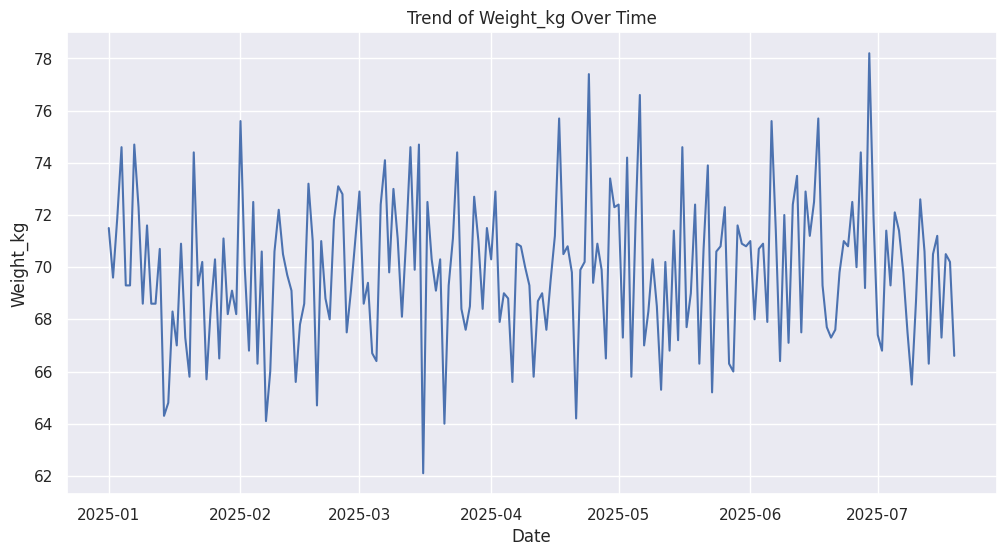

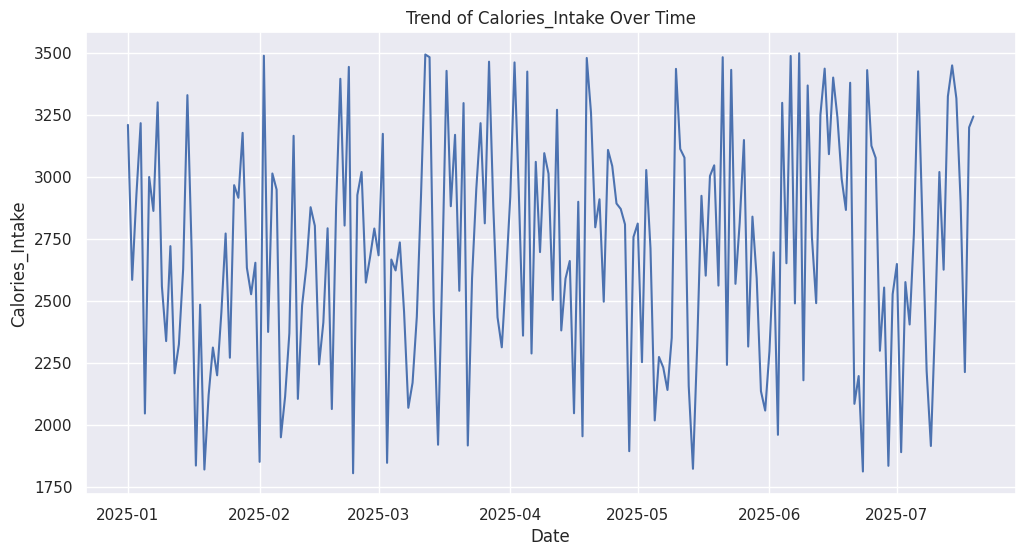

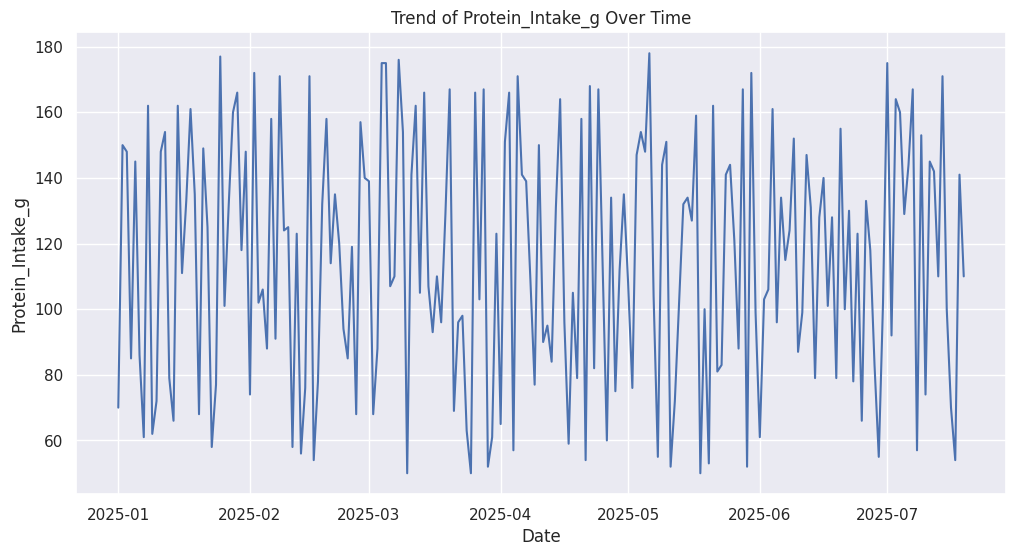

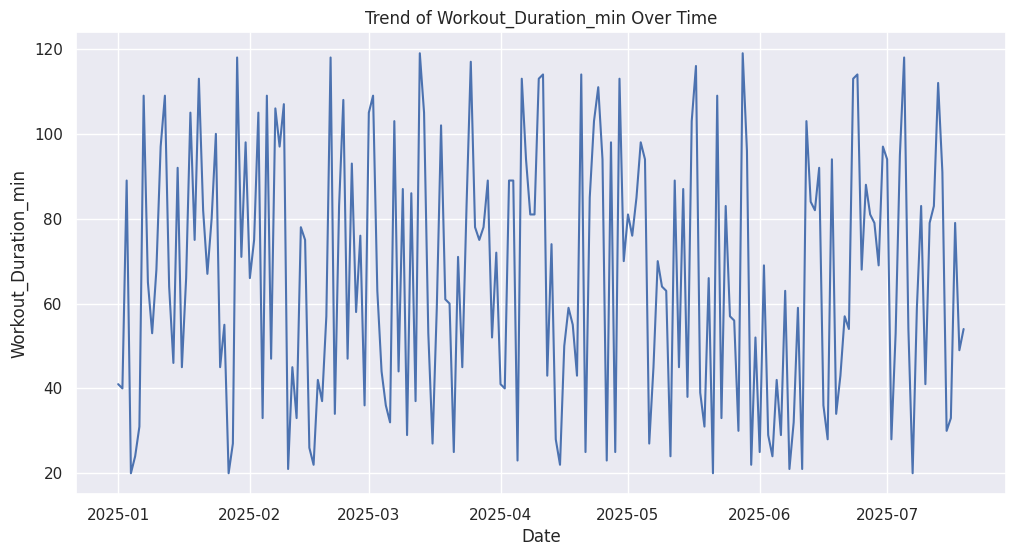

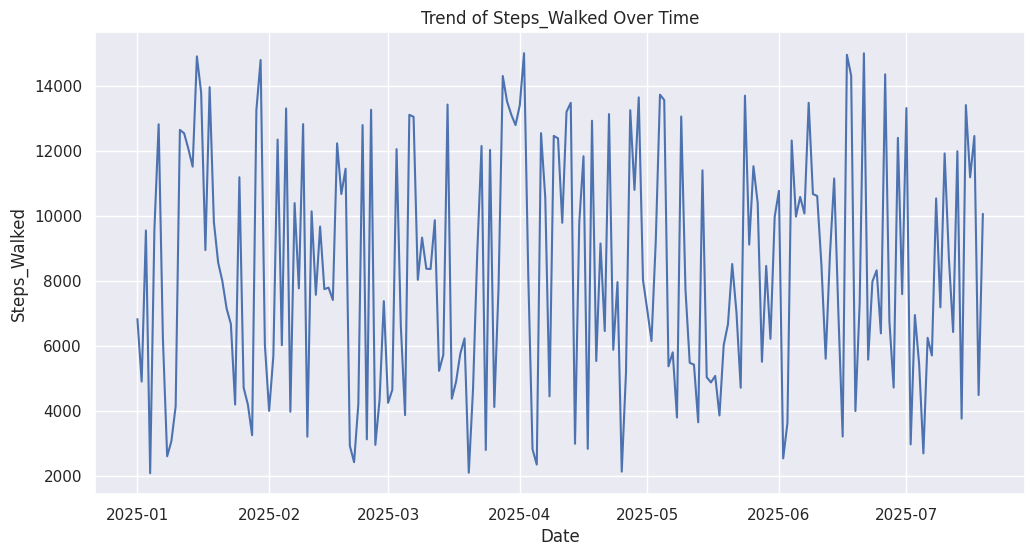

In [17]:
numerical_cols_for_time_series = ['Weight_kg', 'Calories_Intake', 'Protein_Intake_g', 'Workout_Duration_min', 'Steps_Walked']

for col in numerical_cols_for_time_series:
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df, x='Day', y=col)
    plt.title(f'Trend of {col} Over Time')
    plt.xlabel('Date')
    plt.ylabel(col)
    plt.grid(True)
    plt.show()

# Univariate Analysis

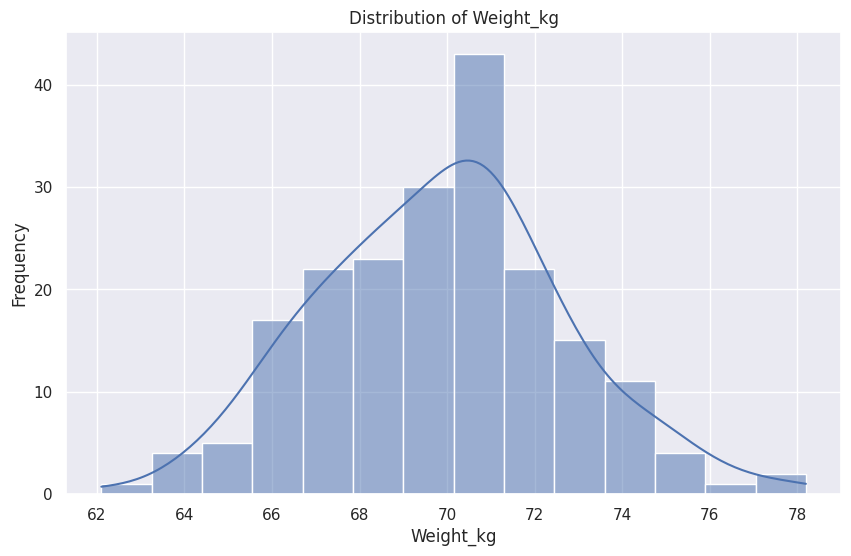

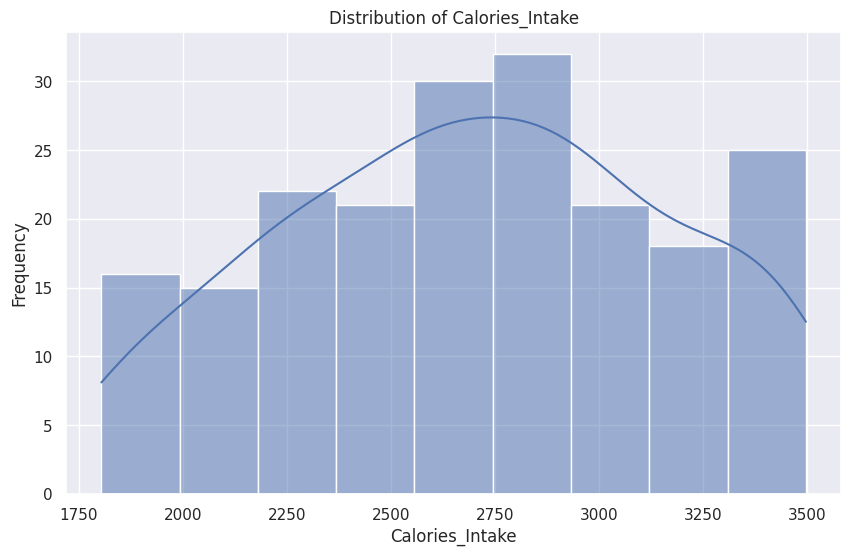

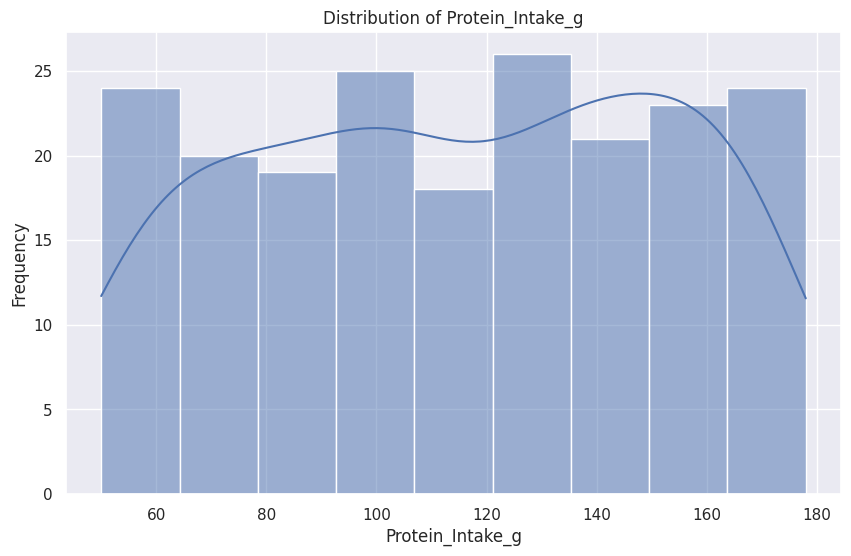

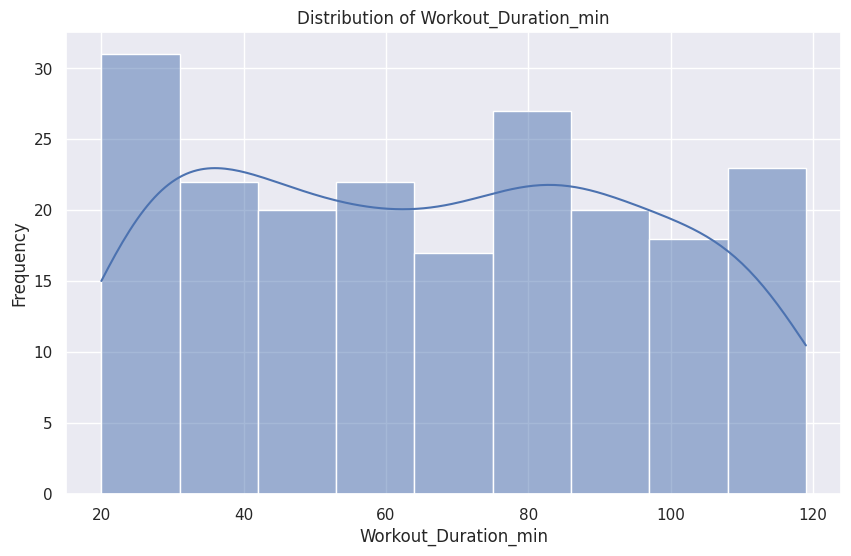

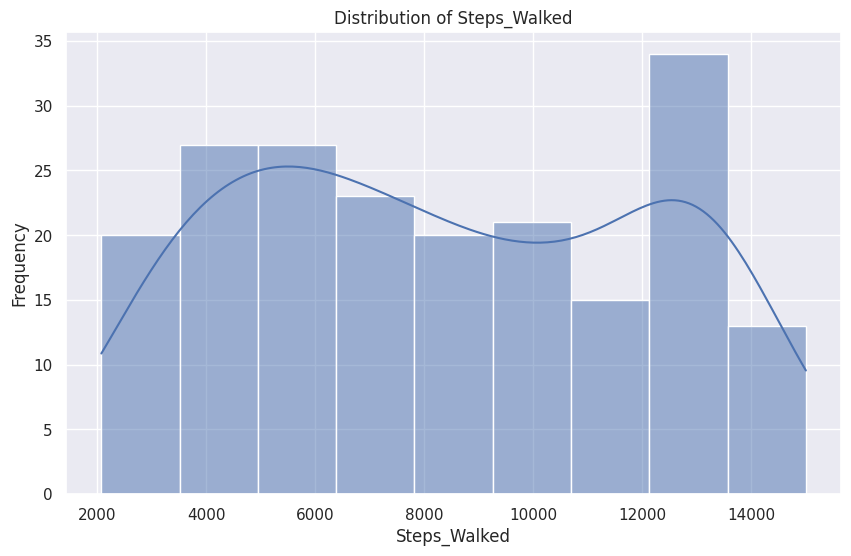

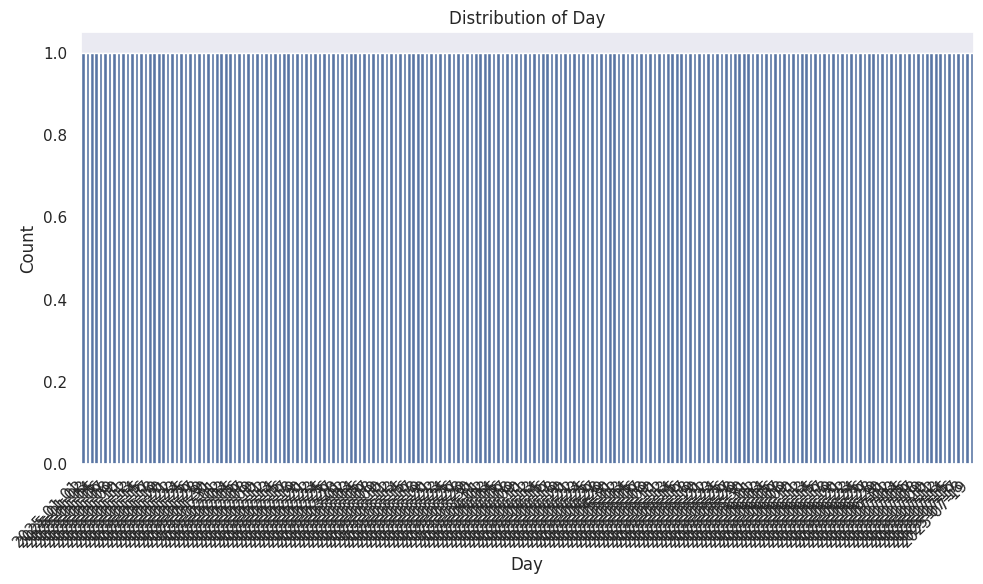

Value counts for Day:
Day
2025-01-01    1
2025-01-02    1
2025-01-03    1
2025-01-04    1
2025-01-05    1
             ..
2025-07-15    1
2025-07-16    1
2025-07-17    1
2025-07-18    1
2025-07-19    1
Name: count, Length: 200, dtype: int64



In [12]:
# Getting a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterating through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Getting a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Iterate through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

# Bivariate Analysis

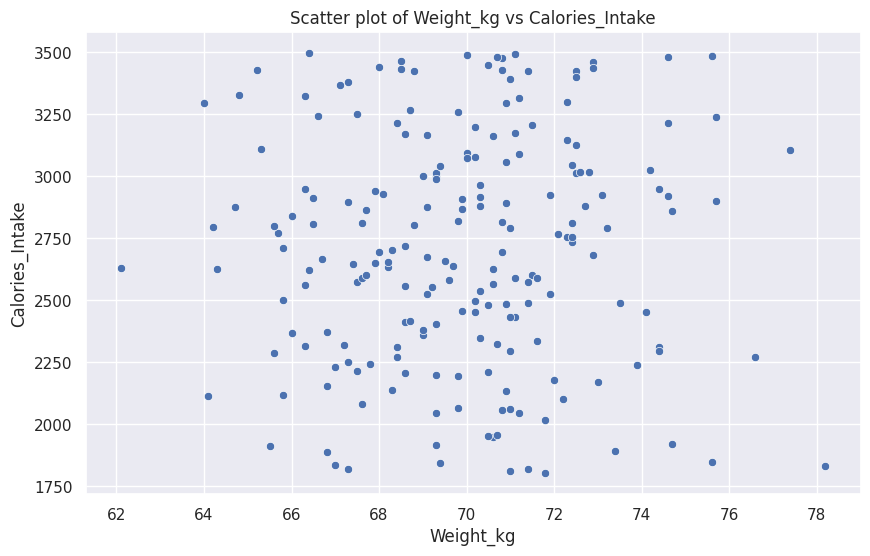

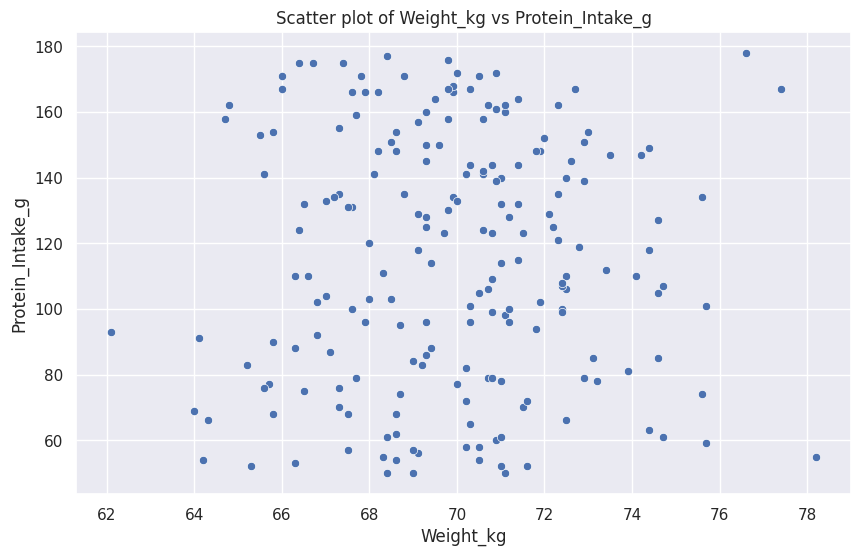

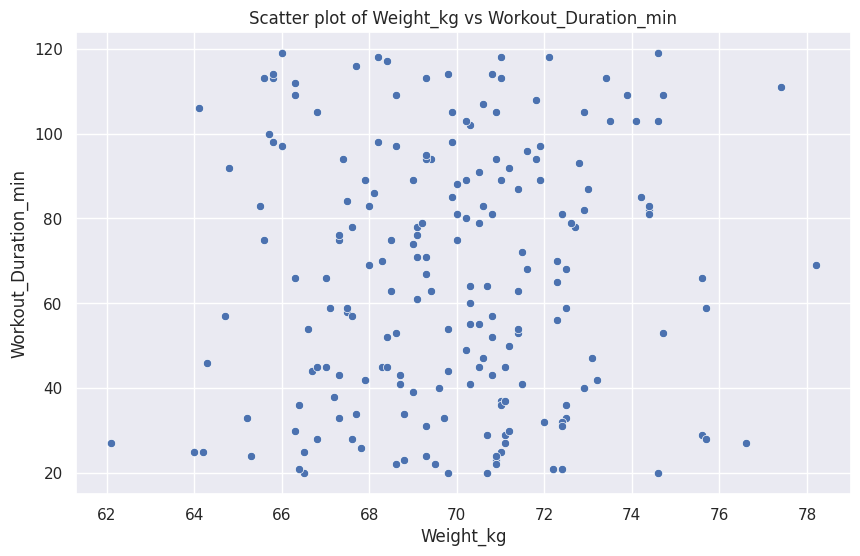

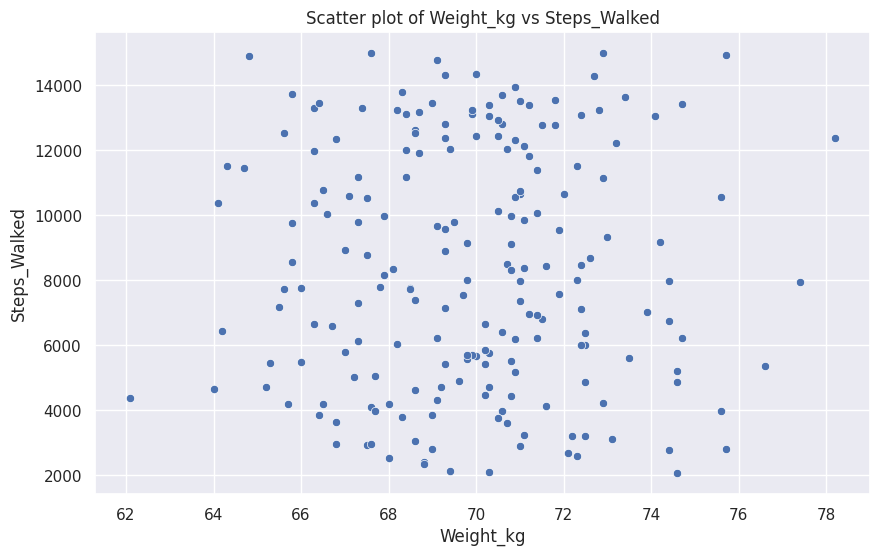

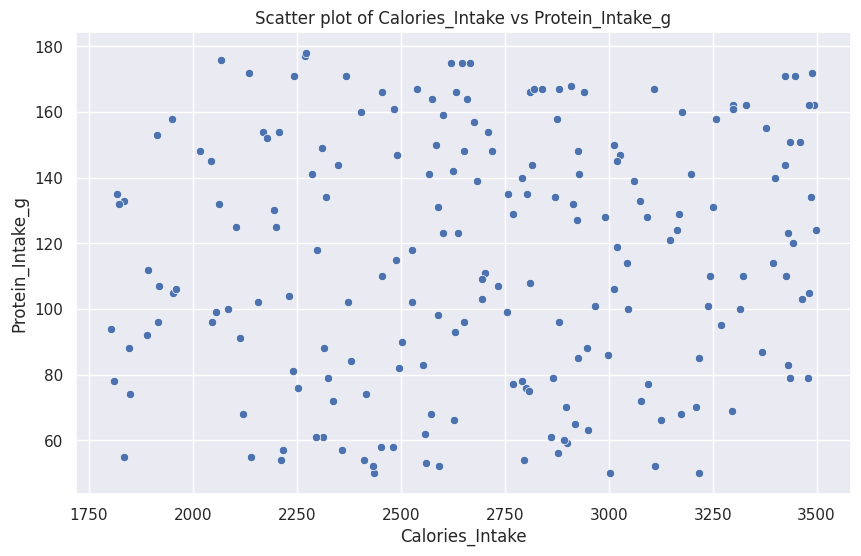

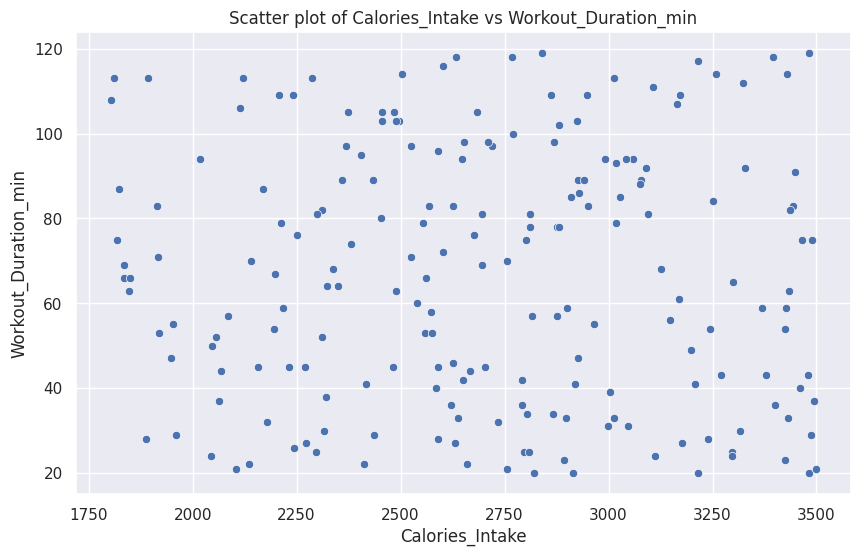

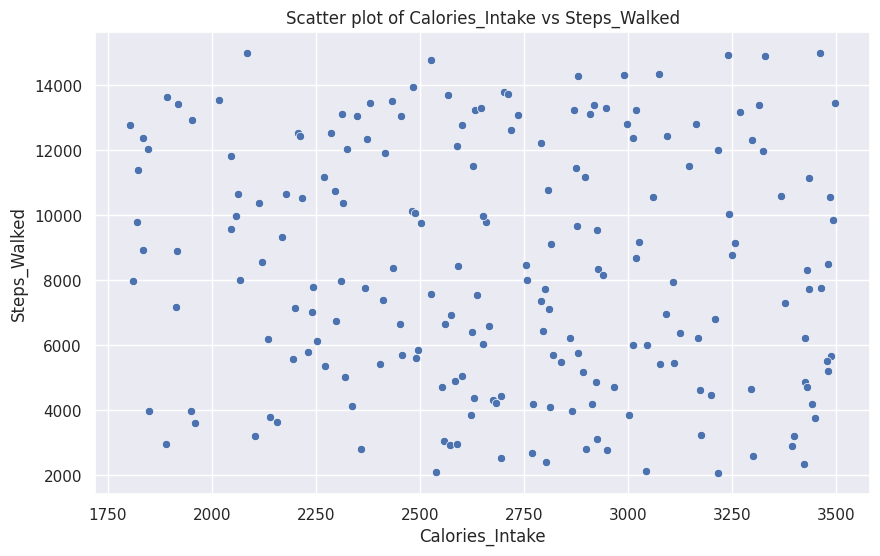

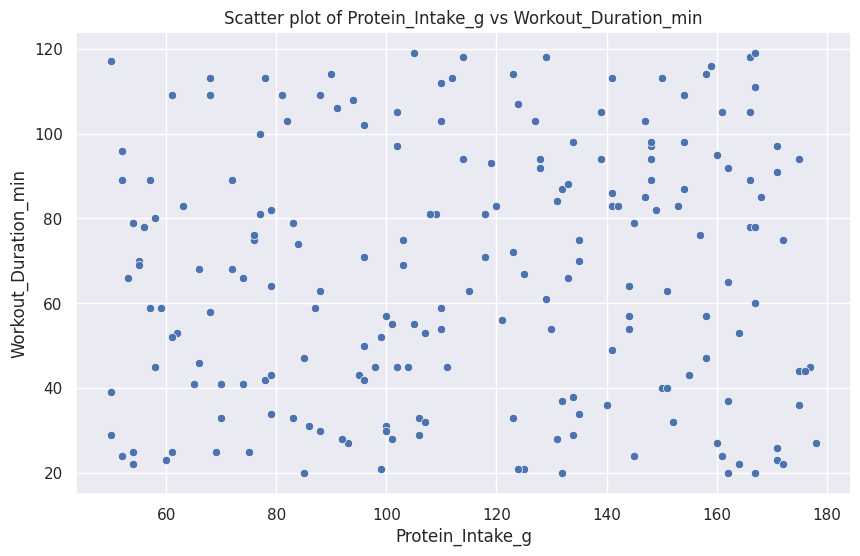

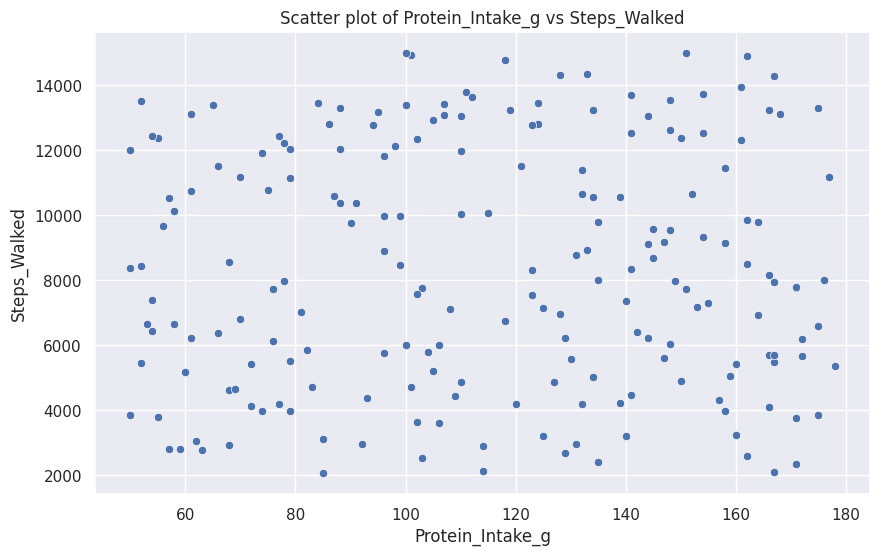

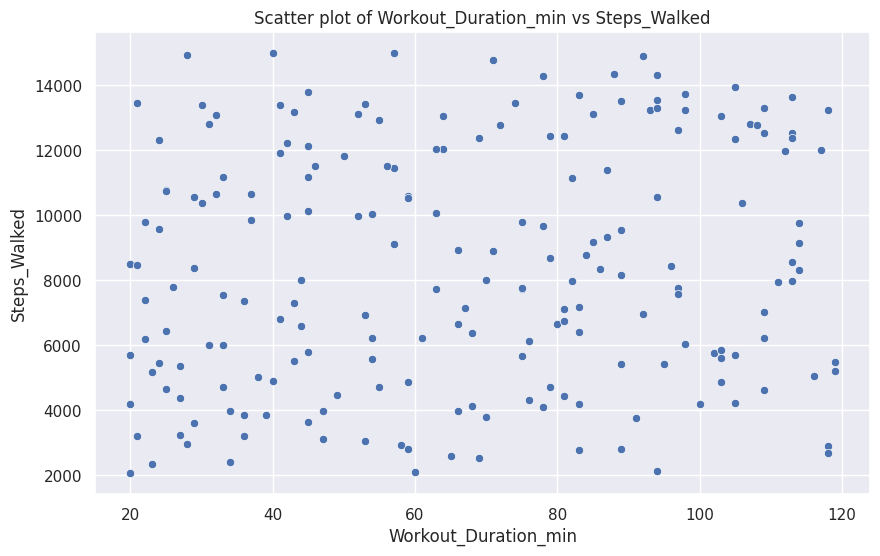

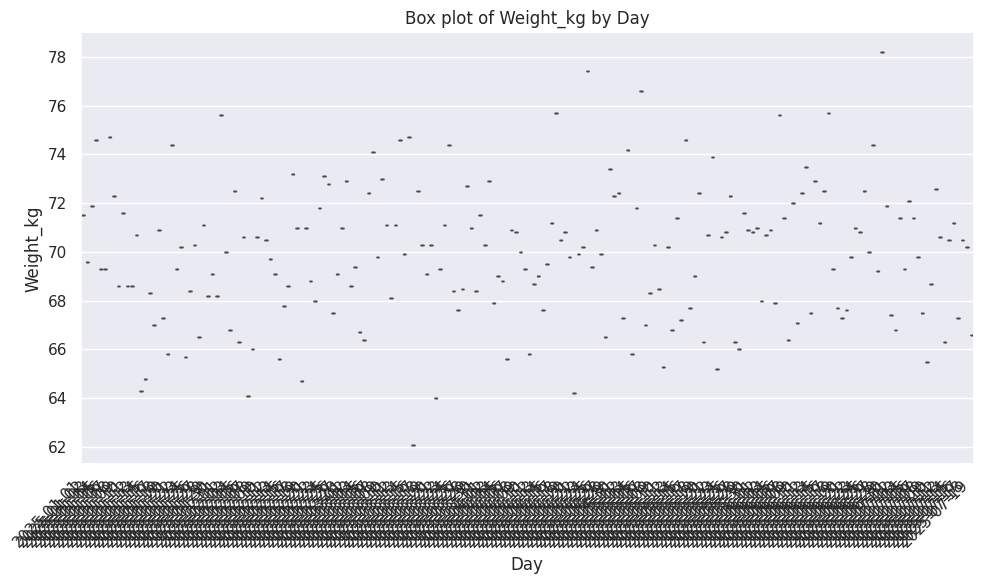

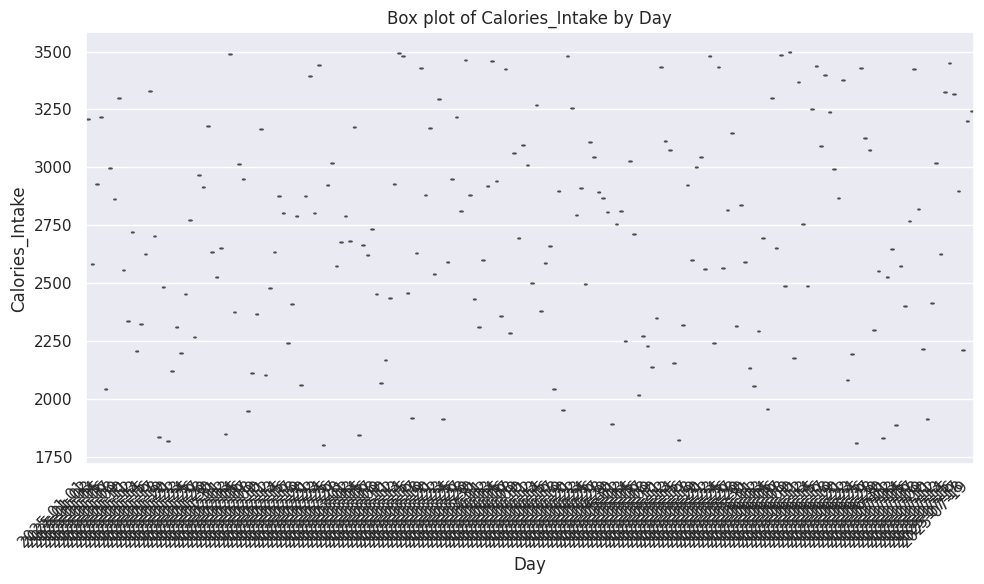

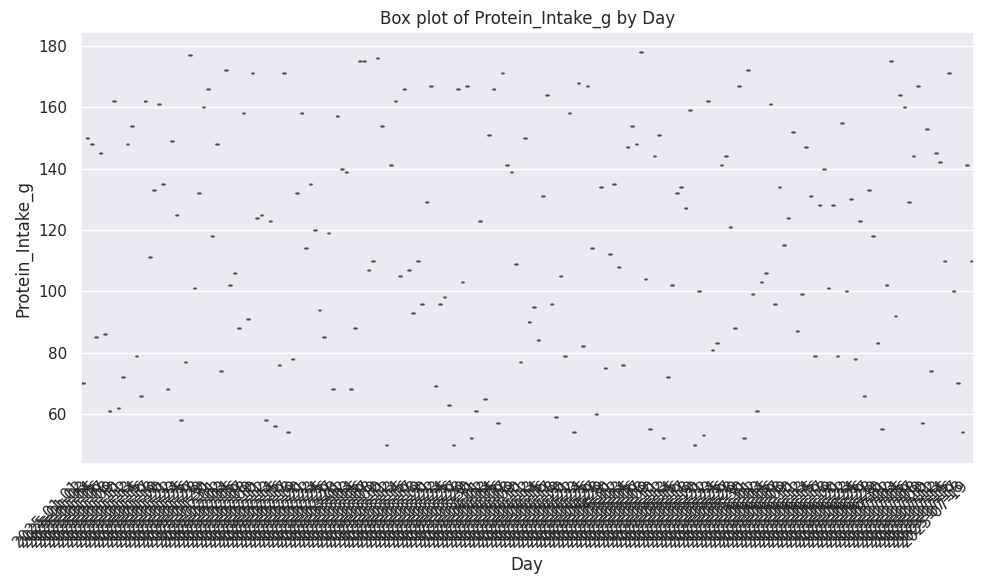

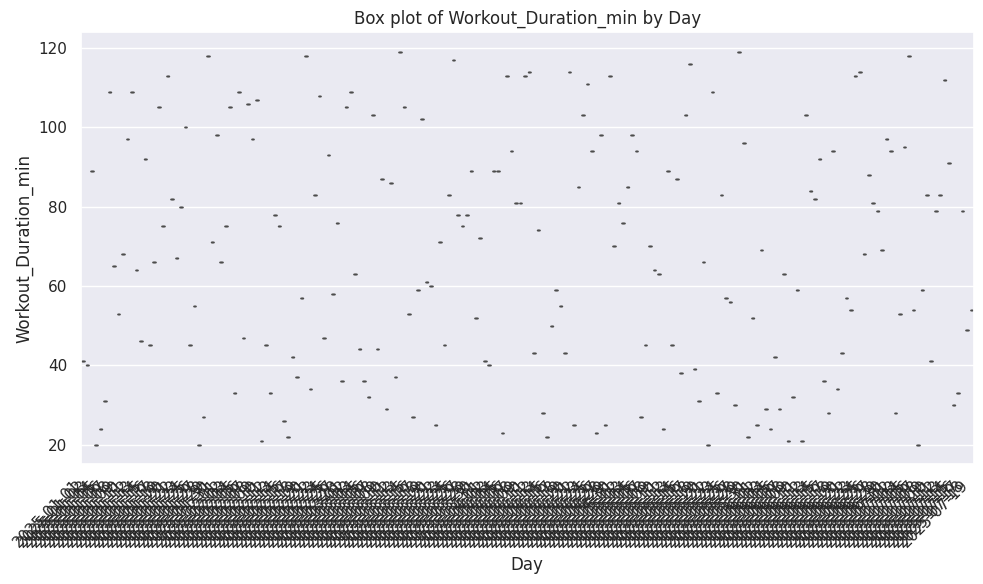

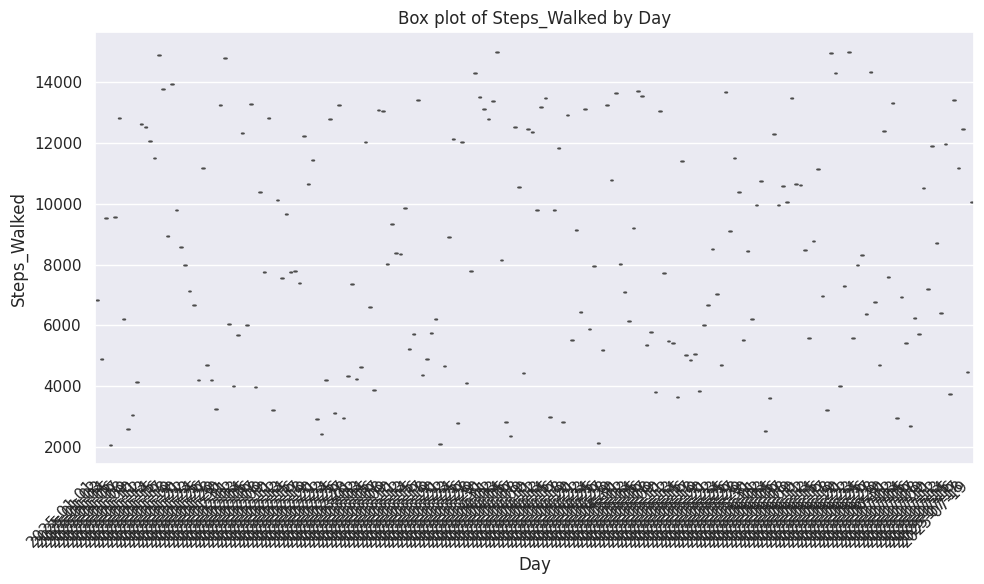

In [13]:
# Numerical-Numerical relationships (Scatter plots)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through pairs of numerical columns and create scatter plots
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        col1 = numerical_cols[i]
        col2 = numerical_cols[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x=col1, y=col2)
        plt.title(f'Scatter plot of {col1} vs {col2}')
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()

# Categorical-Numerical relationships (Box plots)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through categorical and numerical columns and create box plots
for cat_col in categorical_cols:
    for num_col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=cat_col, y=num_col)
        plt.title(f'Box plot of {num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

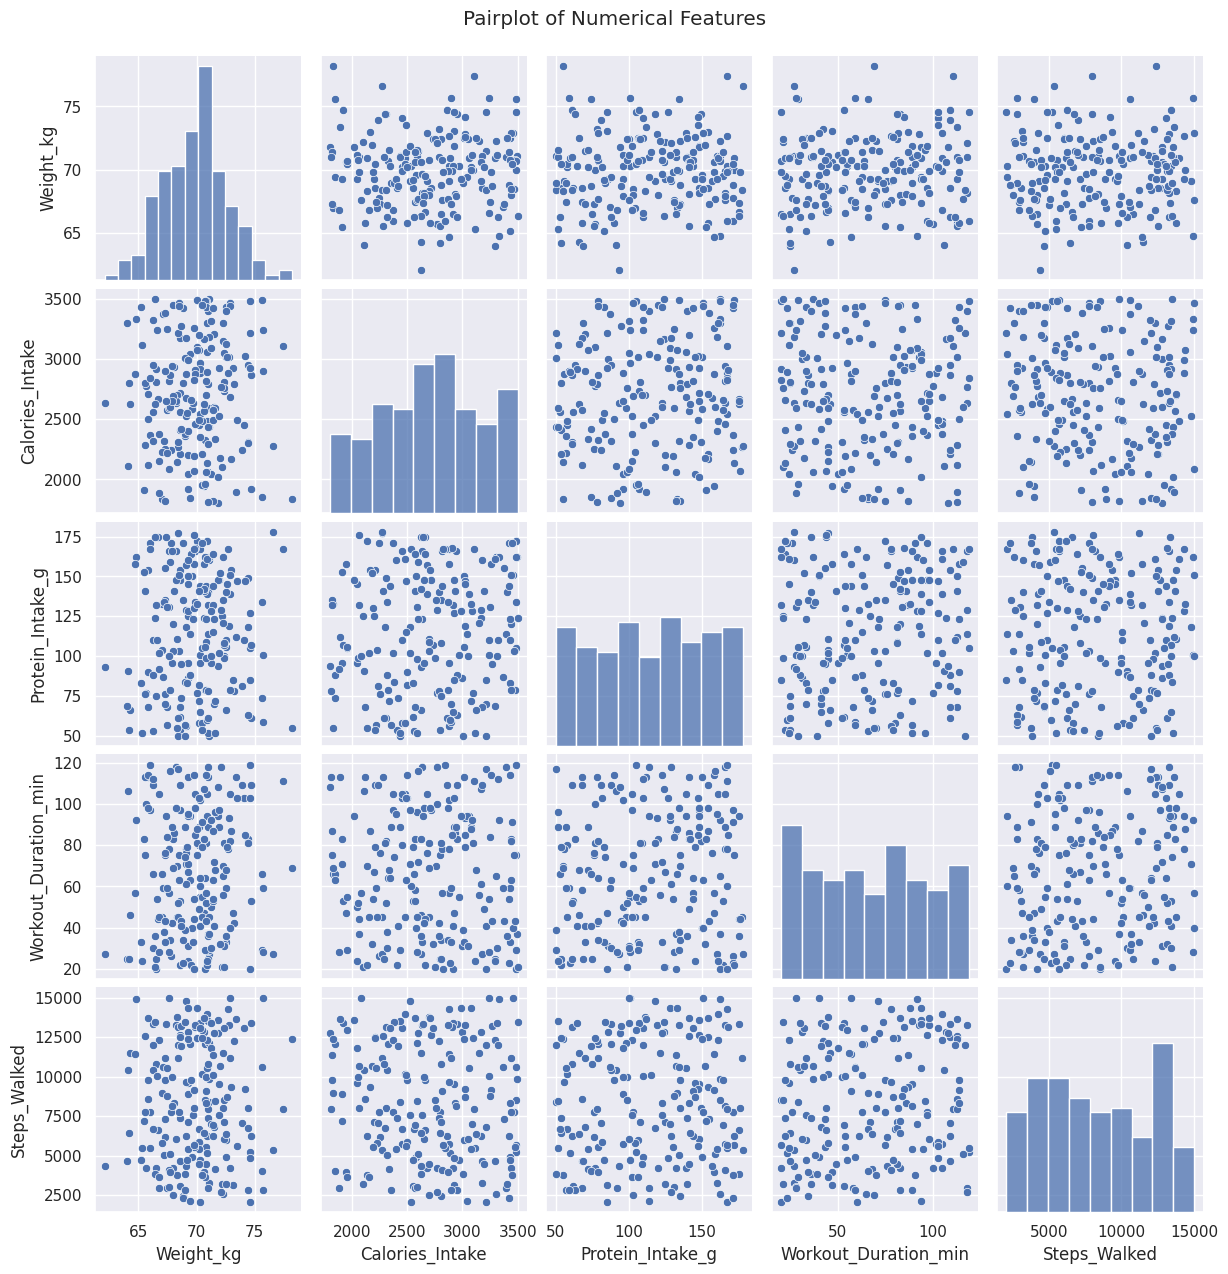

In [14]:
sns.pairplot(df.select_dtypes(include=np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

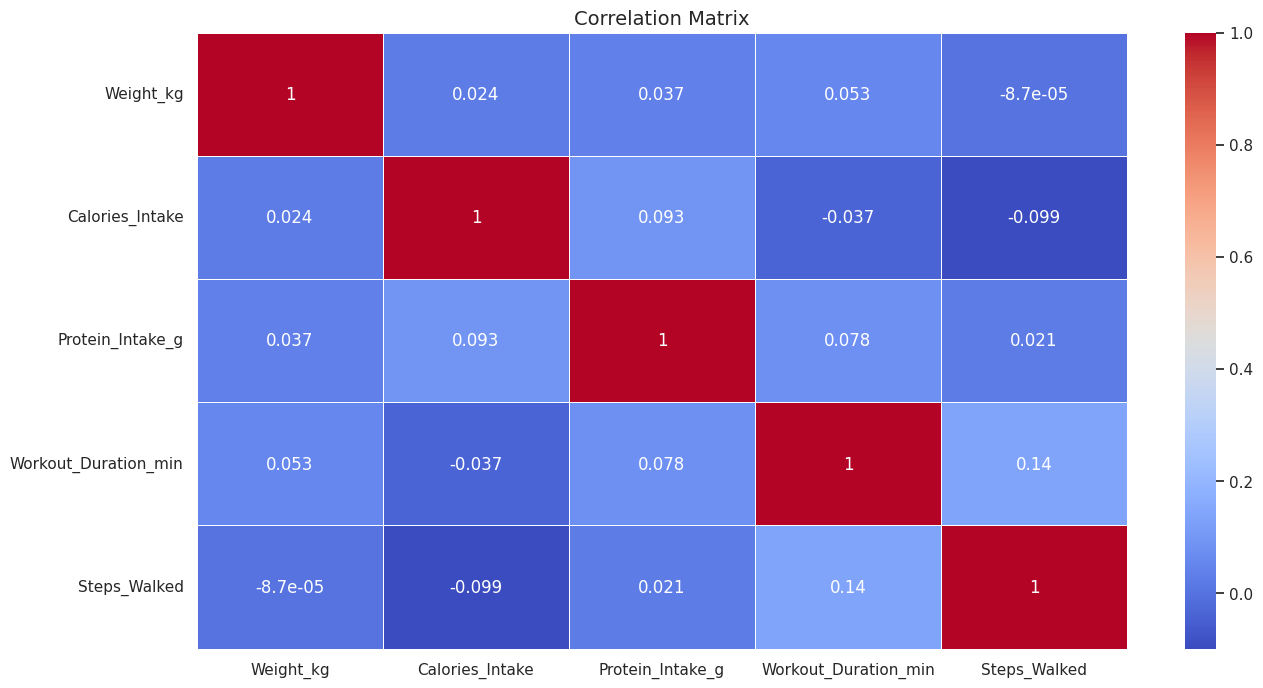

In [15]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Thank you